In [1]:
import xarray as xr 
from anemoi.datasets import open_dataset
import numpy as np
import yaml
import os 
import cfgrib
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Create an ANEMOI dataset

### Variables

In [12]:
ds = xr.open_zarr("Cerra_boz.zarr")

print(ds.dims)
print(ds.coords)

for name in ("level", "levelist", "isobaricInhPa", "plev", "pressure"):
    if name in ds.coords:
        print("Pressure coord:", name, ds.coords[name].values)
for var in ("u","v","t","z","r"):
    if var in ds:
        print(var, ds[var].dims)

FrozenMappingWarningOnValuesAccess({'time': 7544, 'y': 157, 'x': 211, 'level': 9})
Coordinates:
    latitude    (y, x) float64 265kB dask.array<chunksize=(157, 211), meta=np.ndarray>
  * level       (level) float64 72B 1e+03 950.0 900.0 ... 700.0 600.0 500.0
    longitude   (y, x) float64 265kB dask.array<chunksize=(157, 211), meta=np.ndarray>
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * time        (time) datetime64[ns] 60kB 2023-01-01 ... 2025-07-31T21:00:00
    valid_time  datetime64[ns] 8B ...
  * x           (x) int64 2kB 0 1 2 3 4 5 6 7 ... 204 205 206 207 208 209 210
  * y           (y) int64 1kB 0 1 2 3 4 5 6 7 ... 150 151 152 153 154 155 156
Pressure coord: level [1000.  950.  900.  850.  800.  750.  700.  600.  500.]
u ('time', 'level', 'y', 'x')
v ('time', 'level', 'y', 'x')
t ('time', 'level', 'y', 'x')
z ('time', 'level', 'y', 'x')
r ('time', 'level', 'y', 'x')


In [13]:
atmospheric_dims = ("time", "level","y", "x")
atmospheric_fields = [var for var in ds.data_vars if ds[var].dims == atmospheric_dims]
for var in atmospheric_fields:
    print(f" - {var}")

 - r
 - t
 - u
 - v
 - z


In [14]:
surface_dims = ("time", "y", "x")
surface_fields = [var for var in ds.data_vars if ds[var].dims == surface_dims]
for var in surface_fields:
    print(f" - {var}")

 - mcc
 - msl
 - power
 - synthetic_windpower
 - t2m
 - wdir10_cos
 - wdir10_sin
 - wdir_cos100
 - wdir_cos150
 - wdir_cos200
 - wdir_cos50
 - wdir_sin100
 - wdir_sin150
 - wdir_sin200
 - wdir_sin50
 - ws10
 - ws100
 - ws150
 - ws200
 - ws50


In [15]:
constant_dims = ("y","x")
constant_fields = [var for var in ds.data_vars if ds[var].dims == constant_dims]
for var in constant_fields:
    print(f" - {var}")

 - lsm
 - mask
 - surface_geopotential


In [16]:
recipe_keys = [
    "name",
    "description",
    "dates",
    "input",
    "build"
]
recipe = dict.fromkeys(recipe_keys)

In [17]:
recipe["name"] = "Cerra-BOZ-3h-v0"
recipe["description"] = "Toy dataset for wind power prediction in BOZ"

In [18]:
url = "Cerra_boz.zarr"

In [19]:
# Set the dates part of the config
dates = {
    "start": "2023-01-01T00:00:00",
    "end": "2025-07-31T21:00:00",
    "frequency": "3h"
}

# and add it to the config
recipe["dates"] = dates

In [20]:
surface_variables = {
    "xarray-zarr": {                    # The key defining the type, the value is another dictionary with options
        "url": url,                     # The URL of the dataset
        "param": surface_fields,    # The variables to extract                   
    }
}

In [21]:
pressure_levels=[500,600,700,750,800,850,900,950,1000]
upper_air_variables = {
    "xarray-zarr": {                    # The key defining the type, the value is another dictionary with options
        "url": url,                     # The URL of the dataset
        "param": atmospheric_fields,    # The variables to extract                   
    }
}

In [22]:
constant_variables = { 
    "repeated-dates": {      # The key defining the type.
        "mode": "constant",  # The mode, defining here that the fields are constant, other options (climatology, closest) exist
        "source": {          # Which source to use for the constant fields
            "xarray-zarr": { # An xarray-zarr source as defined above
                "url": url,
                "param": ["surface_geopotential", "lsm","mask"],
            }
        }
    }
}

In [23]:
forcings = {
    "forcings": {
        "template": "${input.join.1.xarray-zarr}", # Path to another source in the recipe dictionary.
        "param": [
            "cos_latitude",
            "cos_longitude",
            "sin_latitude",
            "sin_longitude",
            "julian_day",
            "insolation",
        ]
    }
}

In [24]:
# We can combine all these datasets by joining them using the join key in a dictionary
recipe["input"] = {
    "join": [
        constant_variables,
        upper_air_variables,
        surface_variables,
        forcings
    ]
}

In [25]:
build = {
    "group_by": "daily", 
    "variable_naming": "param_levelist",
}

recipe["build"] = build

In [26]:
#I ran this in terminal, not here, but the command is below
print(
    yaml.dump(
        recipe,
        default_flow_style=False
    )
)

build:
  group_by: daily
  variable_naming: param_levelist
dates:
  end: '2025-07-31T21:00:00'
  frequency: 3h
  start: '2023-01-01T00:00:00'
description: Toy dataset for wind power prediction in BOZ
input:
  join:
  - repeated-dates:
      mode: constant
      source:
        xarray-zarr:
          param:
          - surface_geopotential
          - lsm
          - mask
          url: Cerra_boz.zarr
  - xarray-zarr:
      param:
      - r
      - t
      - u
      - v
      - z
      url: Cerra_boz.zarr
  - xarray-zarr:
      param:
      - mcc
      - msl
      - power
      - synthetic_windpower
      - t2m
      - wdir10_cos
      - wdir10_sin
      - wdir_cos100
      - wdir_cos150
      - wdir_cos200
      - wdir_cos50
      - wdir_sin100
      - wdir_sin150
      - wdir_sin200
      - wdir_sin50
      - ws10
      - ws100
      - ws150
      - ws200
      - ws50
      url: Cerra_boz.zarr
  - forcings:
      param:
      - cos_latitude
      - cos_longitude
      - sin_latitude
 

In [27]:
name = recipe["name"]
recipe_path = f"{name}.yaml"
with open(recipe_path, 'w') as file:
    yaml.dump(recipe, file, default_flow_style=False)
dataset_path = "Cerra_boz_Anemoids.zarr"

In [18]:
#!anemoi-datasets create --overwrite {recipe_path} {dataset_path}

In [28]:
!anemoi-datasets inspect Cerra_boz_Anemoids.zarr 

📦 Path          : Cerra_boz_Anemoids.zarr
🔢 Format version: 0.30.0

📅 Start      : 2023-01-01 00:00
📅 End        : 2025-07-31 21:00
⏰ Frequency  : 3h
🚫 Missing    : 0
🌎 Resolution : None
🌎 Field shape: [157, 211]

📐 Shape      : 7,544 × 74 × 1 × 33,127 (68.9 GiB)
💽 Size       : 37.2 GiB (37.2 GiB)
📁 Files      : 7,583

   Index │ Variable             │         Min │      Max │        Mean │      Stdev
   ──────┼──────────────────────┼─────────────┼──────────┼─────────────┼───────────
       0 │ cos_latitude         │    0.548867 │ 0.666868 │    0.606946 │  0.0310695
       1 │ cos_longitude        │    0.983806 │        1 │    0.995883 │ 0.00412394
       2 │ insolation           │           0 │ 0.905152 │    0.198574 │   0.263475
       3 │ julian_day           │           0 │  365.875 │     177.387 │    108.017
       4 │ lsm                  │           0 │        1 │    0.526356 │   0.487836
       5 │ mask                 │           0 │        1 │ 0.000211308 │  0.0145349
       

In [29]:
ds_anemoi= open_dataset(dataset_path)

In [30]:
print(f"The anemoi-datasets {ds_anemoi} has a shape: {ds_anemoi.shape} and contains:")
print(f" - {len(ds_anemoi)} dates: ")
for date in ds_anemoi.dates[0:10]:
    print(f"    - {date} at index {ds_anemoi.dates_interval_to_indices(start=date,end=date)}")
print(f" - {len(ds_anemoi.variables)} variables:")
print(f"    - they are are: {', '.join(ds_anemoi.variables[:])}")
print(f" - {ds_anemoi.grids[0]} gridpoints, originating from a {ds_anemoi.field_shape} grid")

The anemoi-datasets Cerra_boz_Anemoids.zarr has a shape: (7544, 74, 1, 33127) and contains:
 - 7544 dates: 
    - 2023-01-01T00:00:00 at index [0]
    - 2023-01-01T03:00:00 at index [1]
    - 2023-01-01T06:00:00 at index [2]
    - 2023-01-01T09:00:00 at index [3]
    - 2023-01-01T12:00:00 at index [4]
    - 2023-01-01T15:00:00 at index [5]
    - 2023-01-01T18:00:00 at index [6]
    - 2023-01-01T21:00:00 at index [7]
    - 2023-01-02T00:00:00 at index [8]
    - 2023-01-02T03:00:00 at index [9]
 - 74 variables:
    - they are are: cos_latitude, cos_longitude, insolation, julian_day, lsm, mask, mcc, msl, power, r_1000, r_500, r_600, r_700, r_750, r_800, r_850, r_900, r_950, sin_latitude, sin_longitude, surface_geopotential, synthetic_windpower, t2m, t_1000, t_500, t_600, t_700, t_750, t_800, t_850, t_900, t_950, u_1000, u_500, u_600, u_700, u_750, u_800, u_850, u_900, u_950, v_1000, v_500, v_600, v_700, v_750, v_800, v_850, v_900, v_950, wdir10_cos, wdir10_sin, wdir_cos100, wdir_cos150, w

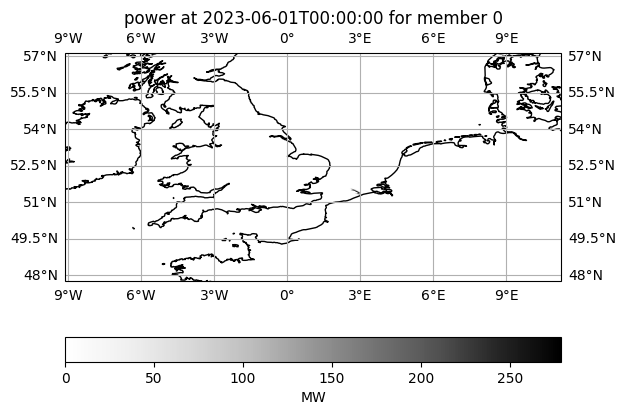

In [36]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

variable = "power"
date = "2023-06-01T00:00:00"
member = 0

values = ds_anemoi[
    ds_anemoi.dates_interval_to_indices(
        start=date,
        end=date
    )[0],
    ds_anemoi.name_to_index[variable],
    member,
    :
]

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.scatter(
    ds_anemoi.longitudes,
    ds_anemoi.latitudes,
    c=values,
    cmap="Greys",
    transform=ccrs.PlateCarree()
)

ax.set_title(f"{variable} at {date} for member {member}")
ax.coastlines()
ax.gridlines(draw_labels=True)

# 🔍 Focus on Belgian offshore zone

plt.colorbar(im, label="MW", orientation="horizontal")
plt.show()


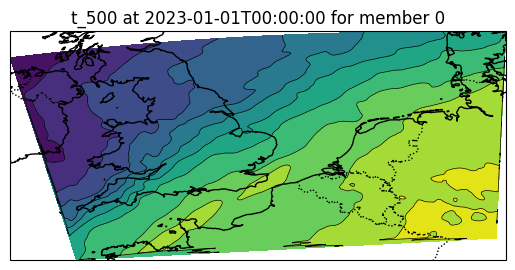

In [11]:
ax = ds_anemoi.plot(variable=variable, date=date, member=member,title=f"{variable} at {date} for member {member}")

### Crop the inner region 

In [5]:
# --- given outer bounds ---
LAT_MIN, LAT_MAX = 49.0, 56.0
LON_MIN, LON_MAX = -6.0, 10.0

# --- inner core (trim 2° on each side) ---
lat_min_i = LAT_MIN + 2.0   # 51.0
lat_max_i = LAT_MAX - 2.0   # 54.0
lon_min_i = LON_MIN + 2.0   # -4.0
lon_max_i = LON_MAX - 2.0   # 8.0

lat = full["latitude"]
lon = full["longitude"]

# points inside the inner box
mask = (lat >= lat_min_i) & (lat <= lat_max_i) & (lon >= lon_min_i) & (lon <= lon_max_i)

# get the smallest y/x index window that covers that mask
yy, xx = np.where(mask.values)
y0, y1 = int(yy.min()), int(yy.max())
x0, x1 = int(xx.min()), int(xx.max())

# slice and save
inner = full.sel(y=slice(y0, y1), x=slice(x0, x1))
inner.to_zarr("Cerra_inner.zarr", mode="w")

print("Saved inner core to Cerra_boz_Anemoids_inner.zarr")
print(f"indices: y=({y0},{y1}) x=({x0},{x1})")
print(f"lat≈[{lat_min_i},{lat_max_i}] lon≈[{lon_min_i},{lon_max_i}]")

Saved inner core to Cerra_boz_Anemoids_inner.zarr
indices: y=(41,112) x=(33,184)
lat≈[51.0,54.0] lon≈[-4.0,8.0]


### Comparison 

In [11]:
ds_outer= open_dataset("Cerra_boz_Anemoids_TOY.zarr")
ds_inner= open_dataset("Cerra_boz_inner_Anemoids_TOY.zarr")

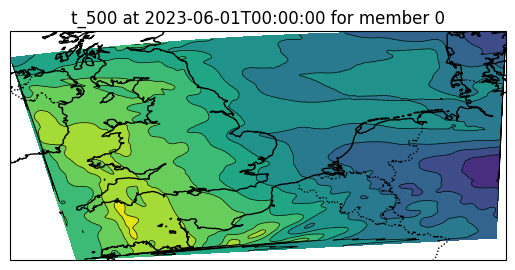

In [5]:
variable = "t_500"
date = "2023-06-01T00:00:00"
member = 0
ax = ds_outer.plot(variable=variable, date=date, member=member,title=f"{variable} at {date} for member {member}")

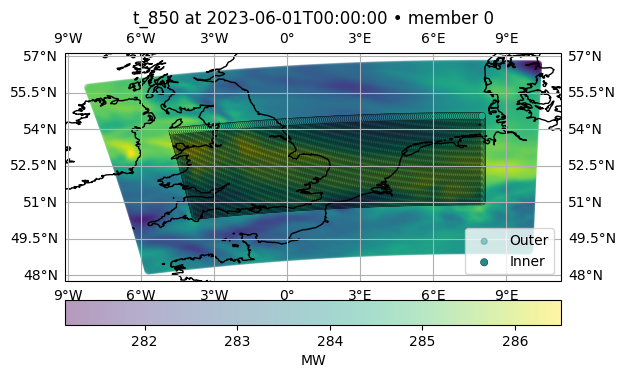

In [8]:
from matplotlib.colors import Normalize
variable = "t_850"
date = "2023-06-01T00:00:00"
member = 0

# --- pick data from BOTH datasets
idx = ds_outer.dates_interval_to_indices(start=date, end=date)[0]

vals_outer = ds_outer[
    idx,
    ds_outer.name_to_index[variable],
    member,
    :
]
lons_outer = ds_outer.longitudes
lats_outer = ds_outer.latitudes

vals_inner = ds_inner[
    idx,
    ds_inner.name_to_index[variable],
    member,
    :
]
lons_inner = ds_inner.longitudes
lats_inner = ds_inner.latitudes

vmin = np.nanmin([np.nanmin(vals_outer), np.nanmin(vals_inner)])
vmax = np.nanmax([np.nanmax(vals_outer), np.nanmax(vals_inner)])
norm = Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': ccrs.PlateCarree()})

h_outer = ax.scatter(
    lons_outer, lats_outer, c=vals_outer, norm=norm, alpha=0.4,
    s=18, transform=ccrs.PlateCarree(), label="Outer"
)

h_inner = ax.scatter(
    lons_inner, lats_inner, c=vals_inner, norm=norm,
    s=28,alpha=1, edgecolors="k", linewidths=0.3, transform=ccrs.PlateCarree(), label="Inner"
)

ax.set_title(f"{variable} at {date} • member {member}")
ax.coastlines()
gl = ax.gridlines(draw_labels=True)

cbar = plt.colorbar(h_outer, ax=ax, orientation="horizontal", pad=0.05)
cbar.set_label("MW")

ax.legend(loc="lower right", frameon=True)
plt.show()


In [2]:
ds_outer= open_dataset("Cerra_Anemoids.zarr")
ds_inner= open_dataset("Cerra_inner_Anemoids.zarr")